# DeepAMR Model Training & Exploration

This notebook provides a complete pipeline for training and evaluating models for:
1. **Organism Classification** - Identifying bacterial species from genome k-mer features
2. **AMR Prediction** - Predicting antimicrobial resistance to multiple drug classes

## Contents
1. [Setup](#1-setup)
2. [Load Data](#2-load-data)
3. [Traditional ML Model Training](#3-traditional-ml-model-training)
4. [Deep Learning Model Training](#4-deep-learning-model-training)
5. [Model Evaluation & Comparison](#5-model-evaluation--comparison)
6. [Organism Classification Results](#6-organism-classification-results)
7. [AMR Prediction Results](#7-amr-prediction-results)
8. [Feature Importance Analysis](#8-feature-importance-analysis)
9. [Making Predictions](#9-making-predictions)
10. [Clinical Impact Analysis](#10-clinical-impact-analysis)
11. [Model Export & Deployment](#11-model-export--deployment)

## 1. Setup

In [1]:
# Standard imports
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn imports
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    hamming_loss
)

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path('.').absolute().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Project root: /Users/jubayer/Projects/DeepAMR
Timestamp: 2026-01-26 23:28:22


In [2]:
# Check for PyTorch availability
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 
                          'mps' if torch.backends.mps.is_available() else 'cpu')
    TORCH_AVAILABLE = True
    print(f"PyTorch available! Using device: {DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available. Using sklearn models only.")
    print("To install PyTorch: pip install torch")

PyTorch available! Using device: mps


In [3]:
# Define paths
DATA_DIR = project_root / 'data' / 'processed' / 'ncbi'
MODELS_DIR = project_root / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"\nData directory exists: {DATA_DIR.exists()}")

Data directory: /Users/jubayer/Projects/DeepAMR/data/processed/ncbi
Models directory: /Users/jubayer/Projects/DeepAMR/models

Data directory exists: True


## 2. Load Data

In [4]:
def load_data(task='organism'):
    """Load preprocessed data for the specified task."""
    prefix = f'ncbi_{task}'
    
    X_train = np.load(DATA_DIR / f'{prefix}_X_train.npy')
    X_val = np.load(DATA_DIR / f'{prefix}_X_val.npy')
    X_test = np.load(DATA_DIR / f'{prefix}_X_test.npy')
    y_train = np.load(DATA_DIR / f'{prefix}_y_train.npy')
    y_val = np.load(DATA_DIR / f'{prefix}_y_val.npy')
    y_test = np.load(DATA_DIR / f'{prefix}_y_test.npy')
    
    with open(DATA_DIR / f'{prefix}_metadata.json') as f:
        metadata = json.load(f)
    
    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'metadata': metadata
    }

In [5]:
# Load organism classification data
organism_data = load_data('organism')

print("Organism Classification Data:")
print(f"  Train: {organism_data['X_train'].shape}")
print(f"  Validation: {organism_data['X_val'].shape}")
print(f"  Test: {organism_data['X_test'].shape}")
print(f"  Classes: {organism_data['metadata']['class_names']}")
print(f"  Number of features: {organism_data['metadata']['n_features']}")

Organism Classification Data:
  Train: (602, 500)
  Validation: (87, 500)
  Test: (173, 500)
  Classes: ['Acinetobacter baumannii', 'Enterococcus faecalis', 'Enterococcus faecium', 'Escherichia coli', 'Klebsiella pneumoniae', 'Pseudomonas aeruginosa', 'Salmonella enterica', 'Staphylococcus aureus']
  Number of features: 500


In [6]:
# Load AMR prediction data
amr_data = load_data('amr')

print("AMR Prediction Data:")
print(f"  Train: {amr_data['X_train'].shape}")
print(f"  Validation: {amr_data['X_val'].shape}")
print(f"  Test: {amr_data['X_test'].shape}")
print(f"  Drug classes: {amr_data['metadata']['class_names']}")
print(f"  Task type: {amr_data['metadata']['task_type']}")

AMR Prediction Data:
  Train: (602, 500)
  Validation: (87, 500)
  Test: (173, 500)
  Drug classes: ['aminoglycoside', 'beta-lactam', 'fosfomycin', 'glycopeptide', 'macrolide', 'phenicol', 'quinolone', 'rifampicin', 'sulfonamide', 'tetracycline', 'trimethoprim']
  Task type: multilabel


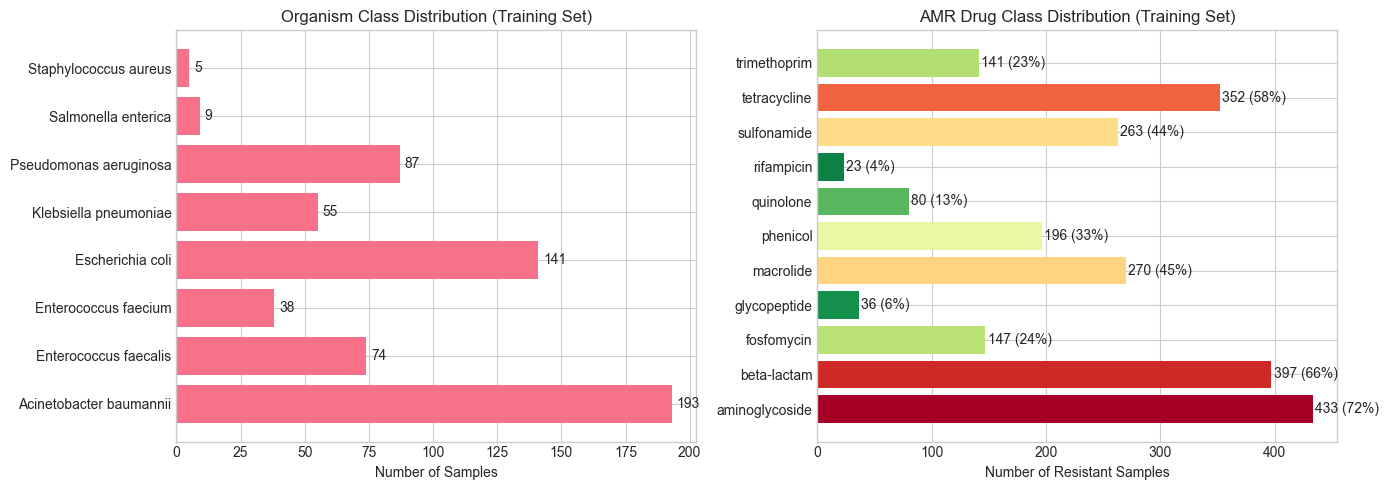

In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Organism class distribution
class_names = organism_data['metadata']['class_names']
train_counts = np.bincount(organism_data['y_train'], minlength=len(class_names))

axes[0].barh(range(len(class_names)), train_counts)
axes[0].set_yticks(range(len(class_names)))
axes[0].set_yticklabels(class_names)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Organism Class Distribution (Training Set)')

for i, v in enumerate(train_counts):
    axes[0].text(v + 2, i, str(v), va='center')

# AMR drug class distribution
drug_names = amr_data['metadata']['class_names']
drug_counts = amr_data['y_train'].sum(axis=0)

colors = plt.cm.RdYlGn_r(drug_counts / drug_counts.max())
axes[1].barh(range(len(drug_names)), drug_counts, color=colors)
axes[1].set_yticks(range(len(drug_names)))
axes[1].set_yticklabels(drug_names)
axes[1].set_xlabel('Number of Resistant Samples')
axes[1].set_title('AMR Drug Class Distribution (Training Set)')

for i, v in enumerate(drug_counts):
    axes[1].text(v + 2, i, f'{int(v)} ({v/len(amr_data["y_train"])*100:.0f}%)', va='center')

plt.tight_layout()
plt.show()

## 3. Traditional ML Model Training

In [8]:
class SklearnTrainer:
    """Trainer for sklearn-based models."""
    
    def __init__(self, task_type='multiclass'):
        self.task_type = task_type
        self.scaler = StandardScaler()
        self.model = None
        self.results = {}
        
    def create_model(self, model_name='random_forest'):
        """Create a model instance."""
        models = {
            'random_forest': RandomForestClassifier(
                n_estimators=200, max_depth=20, min_samples_split=5,
                n_jobs=-1, random_state=42, class_weight='balanced'
            ),
            'extra_trees': ExtraTreesClassifier(
                n_estimators=200, max_depth=20,
                n_jobs=-1, random_state=42, class_weight='balanced'
            ),
            'gradient_boosting': GradientBoostingClassifier(
                n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
            ),
            'logistic_regression': LogisticRegression(
                max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1
            ),
            'mlp': MLPClassifier(
                hidden_layer_sizes=(256, 128, 64), max_iter=500,
                random_state=42, early_stopping=True
            ),
        }
        
        model = models.get(model_name, models['random_forest'])
        
        if self.task_type == 'multilabel':
            model = OneVsRestClassifier(model, n_jobs=-1)
        
        return model
    
    def train(self, X_train, y_train, X_val, y_val, model_name='random_forest'):
        """Train the model."""
        print(f"Training {model_name} ({self.task_type})...")
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        
        # Create and train model
        self.model = self.create_model(model_name)
        self.model.fit(X_train_scaled, y_train)
        
        # Evaluate on validation set
        val_metrics = self.evaluate(X_val_scaled, y_val)
        
        print(f"Validation Results:")
        for k, v in val_metrics.items():
            if isinstance(v, float):
                print(f"  {k}: {v:.4f}")
        
        return val_metrics
    
    def evaluate(self, X, y_true):
        """Evaluate the model."""
        y_pred = self.model.predict(X)
        
        if self.task_type == 'multilabel':
            metrics = {
                'hamming_loss': hamming_loss(y_true, y_pred),
                'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
                'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
                'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
                'micro_precision': precision_score(y_true, y_pred, average='micro', zero_division=0),
                'micro_recall': recall_score(y_true, y_pred, average='micro', zero_division=0),
            }
            
            try:
                y_proba = self.model.predict_proba(X)
                if isinstance(y_proba, list):
                    y_proba = np.array([p[:, 1] for p in y_proba]).T
                metrics['micro_auc'] = roc_auc_score(y_true, y_proba, average='micro')
                metrics['macro_auc'] = roc_auc_score(y_true, y_proba, average='macro')
            except Exception:
                pass
        else:
            metrics = {
                'accuracy': accuracy_score(y_true, y_pred),
                'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
                'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
                'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
                'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
            }
            
            try:
                y_proba = self.model.predict_proba(X)
                metrics['auc'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
            except Exception:
                pass
        
        return metrics
    
    def predict(self, X):
        """Make predictions."""
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)
    
    def predict_proba(self, X):
        """Get prediction probabilities."""
        X_scaled = self.scaler.transform(X)
        proba = self.model.predict_proba(X_scaled)
        if isinstance(proba, list):
            proba = np.array([p[:, 1] for p in proba]).T
        return proba
    
    def save(self, filepath):
        """Save model and scaler."""
        joblib.dump({
            'model': self.model,
            'scaler': self.scaler,
            'task_type': self.task_type,
        }, filepath)
        print(f"Model saved to {filepath}")
    
    @classmethod
    def load(cls, filepath):
        """Load model and scaler."""
        data = joblib.load(filepath)
        trainer = cls(task_type=data['task_type'])
        trainer.model = data['model']
        trainer.scaler = data['scaler']
        return trainer

In [9]:
# Train organism classifier with different models
print("="*60)
print("ORGANISM CLASSIFICATION - Training Multiple Models")
print("="*60)

organism_models = ['random_forest', 'extra_trees', 'logistic_regression', 'mlp']
organism_results = {}

for model_name in organism_models:
    print(f"\n--- {model_name.upper()} ---")
    trainer = SklearnTrainer(task_type='multiclass')
    metrics = trainer.train(
        organism_data['X_train'], organism_data['y_train'],
        organism_data['X_val'], organism_data['y_val'],
        model_name=model_name
    )
    
    # Test evaluation
    X_test_scaled = trainer.scaler.transform(organism_data['X_test'])
    test_metrics = trainer.evaluate(X_test_scaled, organism_data['y_test'])
    
    organism_results[model_name] = {
        'trainer': trainer,
        'val_metrics': metrics,
        'test_metrics': test_metrics
    }
    
    print(f"Test F1: {test_metrics['f1']:.4f}")

ORGANISM CLASSIFICATION - Training Multiple Models

--- RANDOM_FOREST ---
Training random_forest (multiclass)...
Validation Results:
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000
  f1_macro: 1.0000
  auc: 1.0000
Test F1: 1.0000

--- EXTRA_TREES ---
Training extra_trees (multiclass)...
Validation Results:
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000
  f1_macro: 1.0000
  auc: 1.0000
Test F1: 1.0000

--- LOGISTIC_REGRESSION ---
Training logistic_regression (multiclass)...
Validation Results:
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000
  f1_macro: 1.0000
  auc: 1.0000
Test F1: 1.0000

--- MLP ---
Training mlp (multiclass)...
Validation Results:
  accuracy: 0.9770
  precision: 0.9555
  recall: 0.9770
  f1: 0.9659
  f1_macro: 0.7415
  auc: 0.9959
Test F1: 0.9742


In [10]:
# Train AMR predictor with different models
print("="*60)
print("AMR PREDICTION - Training Multiple Models")
print("="*60)

amr_models = ['random_forest', 'extra_trees', 'logistic_regression']
amr_results = {}

for model_name in amr_models:
    print(f"\n--- {model_name.upper()} ---")
    trainer = SklearnTrainer(task_type='multilabel')
    metrics = trainer.train(
        amr_data['X_train'], amr_data['y_train'],
        amr_data['X_val'], amr_data['y_val'],
        model_name=model_name
    )
    
    # Test evaluation
    X_test_scaled = trainer.scaler.transform(amr_data['X_test'])
    test_metrics = trainer.evaluate(X_test_scaled, amr_data['y_test'])
    
    amr_results[model_name] = {
        'trainer': trainer,
        'val_metrics': metrics,
        'test_metrics': test_metrics
    }
    
    print(f"Test Macro F1: {test_metrics['macro_f1']:.4f}")

AMR PREDICTION - Training Multiple Models

--- RANDOM_FOREST ---
Training random_forest (multilabel)...
Validation Results:
  hamming_loss: 0.1735
  micro_f1: 0.7775
  macro_f1: 0.6729
  weighted_f1: 0.7605
  micro_precision: 0.8357
  micro_recall: 0.7268
  micro_auc: 0.9154
  macro_auc: 0.8533
Test Macro F1: 0.6908

--- EXTRA_TREES ---
Training extra_trees (multilabel)...
Validation Results:
  hamming_loss: 0.1797
  micro_f1: 0.7676
  macro_f1: 0.6574
  weighted_f1: 0.7452
  micro_precision: 0.8328
  micro_recall: 0.7118
  micro_auc: 0.9159
  macro_auc: 0.8560
Test Macro F1: 0.6865

--- LOGISTIC_REGRESSION ---
Training logistic_regression (multilabel)...
Validation Results:
  hamming_loss: 0.2205
  micro_f1: 0.7145
  macro_f1: 0.6347
  weighted_f1: 0.7086
  micro_precision: 0.7765
  micro_recall: 0.6617
  micro_auc: 0.8907
  macro_auc: 0.8128
Test Macro F1: 0.7021


## 4. Deep Learning Model Training

In [11]:
if TORCH_AVAILABLE:
    class OrganismClassifier(nn.Module):
        """Deep neural network for organism classification."""
        
        def __init__(self, input_size, hidden_sizes=[256, 128, 64], num_classes=8, dropout_rate=0.3):
            super().__init__()
            
            layers = []
            prev_size = input_size
            
            for hidden_size in hidden_sizes:
                layers.extend([
                    nn.Linear(prev_size, hidden_size),
                    nn.BatchNorm1d(hidden_size),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                ])
                prev_size = hidden_size
            
            layers.append(nn.Linear(prev_size, num_classes))
            self.network = nn.Sequential(*layers)
            self._init_weights()
        
        def _init_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)
        
        def forward(self, x):
            return self.network(x)
    
    
    class AMRPredictor(nn.Module):
        """Deep neural network for multi-label AMR prediction."""
        
        def __init__(self, input_size, hidden_sizes=[512, 256, 128], num_classes=11, dropout_rate=0.4):
            super().__init__()
            
            # Shared feature extractor
            shared_layers = []
            prev_size = input_size
            
            for hidden_size in hidden_sizes[:-1]:
                shared_layers.extend([
                    nn.Linear(prev_size, hidden_size),
                    nn.BatchNorm1d(hidden_size),
                    nn.LeakyReLU(0.1),
                    nn.Dropout(dropout_rate),
                ])
                prev_size = hidden_size
            
            self.shared = nn.Sequential(*shared_layers)
            
            # Drug-class specific heads
            self.drug_heads = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(prev_size, hidden_sizes[-1]),
                    nn.BatchNorm1d(hidden_sizes[-1]),
                    nn.LeakyReLU(0.1),
                    nn.Dropout(dropout_rate * 0.5),
                    nn.Linear(hidden_sizes[-1], 1),
                )
                for _ in range(num_classes)
            ])
        
        def forward(self, x):
            shared_features = self.shared(x)
            outputs = [head(shared_features) for head in self.drug_heads]
            return torch.cat(outputs, dim=1)
    
    print("Deep learning model classes defined successfully!")
else:
    print("Skipping deep learning models (PyTorch not available)")

Deep learning model classes defined successfully!


In [12]:
if TORCH_AVAILABLE:
    class DeepTrainer:
        """Trainer for PyTorch deep learning models."""
        
        def __init__(self, model, task_type='multiclass', device=DEVICE):
            self.model = model.to(device)
            self.device = device
            self.task_type = task_type
            self.scaler = StandardScaler()
            self.history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
        
        def train(self, X_train, y_train, X_val, y_val, 
                  epochs=50, batch_size=32, lr=0.001, patience=10):
            """Train the model."""
            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_val_scaled = self.scaler.transform(X_val)
            
            # Create dataloaders
            train_dataset = TensorDataset(
                torch.FloatTensor(X_train_scaled),
                torch.LongTensor(y_train) if self.task_type == 'multiclass' else torch.FloatTensor(y_train)
            )
            val_dataset = TensorDataset(
                torch.FloatTensor(X_val_scaled),
                torch.LongTensor(y_val) if self.task_type == 'multiclass' else torch.FloatTensor(y_val)
            )
            
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size)
            
            # Setup training
            optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
            
            if self.task_type == 'multiclass':
                criterion = nn.CrossEntropyLoss()
            else:
                criterion = nn.BCEWithLogitsLoss()
            
            best_val_loss = float('inf')
            patience_counter = 0
            
            print(f"Training on {self.device}...")
            
            for epoch in range(epochs):
                # Training phase
                self.model.train()
                train_loss = 0
                train_preds, train_labels = [], []
                
                for batch_x, batch_y in train_loader:
                    batch_x = batch_x.to(self.device)
                    batch_y = batch_y.to(self.device)
                    
                    optimizer.zero_grad()
                    outputs = self.model(batch_x)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    optimizer.step()
                    
                    train_loss += loss.item()
                    
                    if self.task_type == 'multiclass':
                        preds = outputs.argmax(dim=1).cpu().numpy()
                    else:
                        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
                    
                    train_preds.extend(preds)
                    train_labels.extend(batch_y.cpu().numpy())
                
                train_loss /= len(train_loader)
                
                if self.task_type == 'multiclass':
                    train_f1 = f1_score(train_labels, train_preds, average='macro')
                else:
                    train_f1 = f1_score(train_labels, train_preds, average='macro')
                
                # Validation phase
                self.model.eval()
                val_loss = 0
                val_preds, val_labels = [], []
                
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x = batch_x.to(self.device)
                        batch_y = batch_y.to(self.device)
                        
                        outputs = self.model(batch_x)
                        loss = criterion(outputs, batch_y)
                        val_loss += loss.item()
                        
                        if self.task_type == 'multiclass':
                            preds = outputs.argmax(dim=1).cpu().numpy()
                        else:
                            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
                        
                        val_preds.extend(preds)
                        val_labels.extend(batch_y.cpu().numpy())
                
                val_loss /= len(val_loader)
                
                if self.task_type == 'multiclass':
                    val_f1 = f1_score(val_labels, val_preds, average='macro')
                else:
                    val_f1 = f1_score(val_labels, val_preds, average='macro')
                
                # Update scheduler
                scheduler.step(val_loss)
                
                # Record history
                self.history['train_loss'].append(train_loss)
                self.history['val_loss'].append(val_loss)
                self.history['train_f1'].append(train_f1)
                self.history['val_f1'].append(val_f1)
                
                # Early stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    best_model_state = self.model.state_dict().copy()
                else:
                    patience_counter += 1
                
                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | "
                          f"Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
                
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
            
            # Load best model
            self.model.load_state_dict(best_model_state)
            
            return self.history
        
        def evaluate(self, X, y_true):
            """Evaluate the model."""
            X_scaled = self.scaler.transform(X)
            X_tensor = torch.FloatTensor(X_scaled).to(self.device)
            
            self.model.eval()
            with torch.no_grad():
                outputs = self.model(X_tensor)
                
                if self.task_type == 'multiclass':
                    probs = torch.softmax(outputs, dim=1).cpu().numpy()
                    preds = outputs.argmax(dim=1).cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).cpu().numpy()
                    preds = (probs > 0.5).astype(int)
            
            if self.task_type == 'multiclass':
                metrics = {
                    'accuracy': accuracy_score(y_true, preds),
                    'f1': f1_score(y_true, preds, average='weighted'),
                    'f1_macro': f1_score(y_true, preds, average='macro'),
                }
                try:
                    metrics['auc'] = roc_auc_score(y_true, probs, multi_class='ovr', average='weighted')
                except Exception:
                    pass
            else:
                metrics = {
                    'micro_f1': f1_score(y_true, preds, average='micro'),
                    'macro_f1': f1_score(y_true, preds, average='macro'),
                    'hamming_loss': hamming_loss(y_true, preds),
                }
                try:
                    metrics['micro_auc'] = roc_auc_score(y_true, probs, average='micro')
                    metrics['macro_auc'] = roc_auc_score(y_true, probs, average='macro')
                except Exception:
                    pass
            
            return metrics, preds, probs
        
        def save(self, filepath):
            """Save model."""
            torch.save({
                'model_state_dict': self.model.state_dict(),
                'scaler': self.scaler,
                'history': self.history,
            }, filepath)
            print(f"Model saved to {filepath}")
    
    print("DeepTrainer class defined successfully!")
else:
    print("Skipping DeepTrainer (PyTorch not available)")

DeepTrainer class defined successfully!


In [14]:
# Train deep learning models if PyTorch is available
dl_organism_results = None
dl_amr_results = None

if TORCH_AVAILABLE:
    print("="*60)
    print("DEEP LEARNING - Organism Classification")
    print("="*60)
    
    # Create organism classifier
    org_model = OrganismClassifier(
        input_size=organism_data['X_train'].shape[1],
        num_classes=len(organism_data['metadata']['class_names'])
    )
    
    org_trainer = DeepTrainer(org_model, task_type='multiclass')
    org_history = org_trainer.train(
        organism_data['X_train'], organism_data['y_train'],
        organism_data['X_val'], organism_data['y_val'],
        epochs=50, batch_size=32
    )
    
    dl_organism_metrics, dl_organism_preds, dl_organism_probs = org_trainer.evaluate(
        organism_data['X_test'], organism_data['y_test']
    )
    
    print(f"\nDeep Learning Test Results:")
    for k, v in dl_organism_metrics.items():
        print(f"  {k}: {v:.4f}")
    
    dl_organism_results = {
        'trainer': org_trainer,
        'history': org_history,
        'test_metrics': dl_organism_metrics,
        'predictions': dl_organism_preds,
        'probabilities': dl_organism_probs
    }
else:
    print("Skipping deep learning training (PyTorch not available)")

DEEP LEARNING - Organism Classification
Training on mps...
Epoch 10/50 | Train Loss: 0.0314 | Val Loss: 0.0002 | Train F1: 0.9775 | Val F1: 1.0000
Epoch 20/50 | Train Loss: 0.0102 | Val Loss: 0.0000 | Train F1: 0.9919 | Val F1: 1.0000
Epoch 30/50 | Train Loss: 0.0053 | Val Loss: 0.0000 | Train F1: 0.9984 | Val F1: 1.0000
Epoch 40/50 | Train Loss: 0.0070 | Val Loss: 0.0000 | Train F1: 0.9923 | Val F1: 1.0000
Epoch 50/50 | Train Loss: 0.0043 | Val Loss: 0.0000 | Train F1: 1.0000 | Val F1: 1.0000

Deep Learning Test Results:
  accuracy: 1.0000
  f1: 1.0000
  f1_macro: 1.0000
  auc: 1.0000


In [15]:
if TORCH_AVAILABLE:
    print("="*60)
    print("DEEP LEARNING - AMR Prediction")
    print("="*60)
    
    # Create AMR predictor
    amr_model = AMRPredictor(
        input_size=amr_data['X_train'].shape[1],
        num_classes=len(amr_data['metadata']['class_names'])
    )
    
    amr_trainer = DeepTrainer(amr_model, task_type='multilabel')
    amr_history = amr_trainer.train(
        amr_data['X_train'], amr_data['y_train'],
        amr_data['X_val'], amr_data['y_val'],
        epochs=50, batch_size=32
    )
    
    dl_amr_metrics, dl_amr_preds, dl_amr_probs = amr_trainer.evaluate(
        amr_data['X_test'], amr_data['y_test']
    )
    
    print(f"\nDeep Learning Test Results:")
    for k, v in dl_amr_metrics.items():
        print(f"  {k}: {v:.4f}")
    
    dl_amr_results = {
        'trainer': amr_trainer,
        'history': amr_history,
        'test_metrics': dl_amr_metrics,
        'predictions': dl_amr_preds,
        'probabilities': dl_amr_probs
    }
else:
    print("Skipping AMR deep learning training (PyTorch not available)")

DEEP LEARNING - AMR Prediction
Training on mps...
Epoch 10/50 | Train Loss: 0.2979 | Val Loss: 0.3945 | Train F1: 0.7216 | Val F1: 0.6684
Epoch 20/50 | Train Loss: 0.2271 | Val Loss: 0.4149 | Train F1: 0.7667 | Val F1: 0.6634
Early stopping at epoch 21

Deep Learning Test Results:
  micro_f1: 0.7844
  macro_f1: 0.6847
  hamming_loss: 0.1540
  micro_auc: 0.9209
  macro_auc: 0.8758


## 5. Model Evaluation & Comparison

In [15]:
# Compare organism classification models
print("="*60)
print("ORGANISM CLASSIFICATION - Model Comparison")
print("="*60)

comparison_data = []

for model_name, results in organism_results.items():
    comparison_data.append({
        'Model': model_name,
        'Type': 'sklearn',
        'Accuracy': results['test_metrics'].get('accuracy', 0),
        'F1 (Weighted)': results['test_metrics'].get('f1', 0),
        'F1 (Macro)': results['test_metrics'].get('f1_macro', 0),
        'AUC': results['test_metrics'].get('auc', 0),
    })

if dl_organism_results:
    comparison_data.append({
        'Model': 'deep_learning',
        'Type': 'pytorch',
        'Accuracy': dl_organism_results['test_metrics'].get('accuracy', 0),
        'F1 (Weighted)': dl_organism_results['test_metrics'].get('f1', 0),
        'F1 (Macro)': dl_organism_results['test_metrics'].get('f1_macro', 0),
        'AUC': dl_organism_results['test_metrics'].get('auc', 0),
    })

org_comparison_df = pd.DataFrame(comparison_data)
org_comparison_df = org_comparison_df.sort_values('F1 (Weighted)', ascending=False)
display(org_comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'F1 (Weighted)': '{:.4f}',
    'F1 (Macro)': '{:.4f}',
    'AUC': '{:.4f}',
}).background_gradient(subset=['F1 (Weighted)', 'Accuracy'], cmap='RdYlGn'))

ORGANISM CLASSIFICATION - Model Comparison


,Model,Type,Accuracy,F1 (Weighted),F1 (Macro),AUC
0,random_forest,sklearn,1.0000,1.0000,1.0000,1.0000
1,extra_trees,sklearn,1.0000,1.0000,1.0000,1.0000
2,logistic_regression,sklearn,1.0000,1.0000,1.0000,1.0000
4,deep_learning,pytorch,1.0000,1.0000,1.0000,1.0000
3,mlp,sklearn,0.9827,0.9742,0.7418,0.9968


In [16]:
# Compare AMR prediction models
print("="*60)
print("AMR PREDICTION - Model Comparison")
print("="*60)

amr_comparison_data = []

for model_name, results in amr_results.items():
    amr_comparison_data.append({
        'Model': model_name,
        'Type': 'sklearn',
        'Micro F1': results['test_metrics'].get('micro_f1', 0),
        'Macro F1': results['test_metrics'].get('macro_f1', 0),
        'Weighted F1': results['test_metrics'].get('weighted_f1', 0),
        'Micro AUC': results['test_metrics'].get('micro_auc', 0),
        'Hamming Loss': results['test_metrics'].get('hamming_loss', 0),
    })

if dl_amr_results:
    amr_comparison_data.append({
        'Model': 'deep_learning',
        'Type': 'pytorch',
        'Micro F1': dl_amr_results['test_metrics'].get('micro_f1', 0),
        'Macro F1': dl_amr_results['test_metrics'].get('macro_f1', 0),
        'Weighted F1': dl_amr_results['test_metrics'].get('weighted_f1', 0),
        'Micro AUC': dl_amr_results['test_metrics'].get('micro_auc', 0),
        'Hamming Loss': dl_amr_results['test_metrics'].get('hamming_loss', 0),
    })

amr_comparison_df = pd.DataFrame(amr_comparison_data)
amr_comparison_df = amr_comparison_df.sort_values('Macro F1', ascending=False)
display(amr_comparison_df.style.format({
    'Micro F1': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Weighted F1': '{:.4f}',
    'Micro AUC': '{:.4f}',
    'Hamming Loss': '{:.4f}',
}).background_gradient(subset=['Macro F1', 'Micro F1'], cmap='RdYlGn'))

AMR PREDICTION - Model Comparison


,Model,Type,Micro F1,Macro F1,Weighted F1,Micro AUC,Hamming Loss
2,logistic_regression,sklearn,0.7663,0.7021,0.7646,0.9040,0.1734
0,random_forest,sklearn,0.7991,0.6908,0.7828,0.9342,0.1482
1,extra_trees,sklearn,0.7954,0.6865,0.7794,0.9348,0.1503


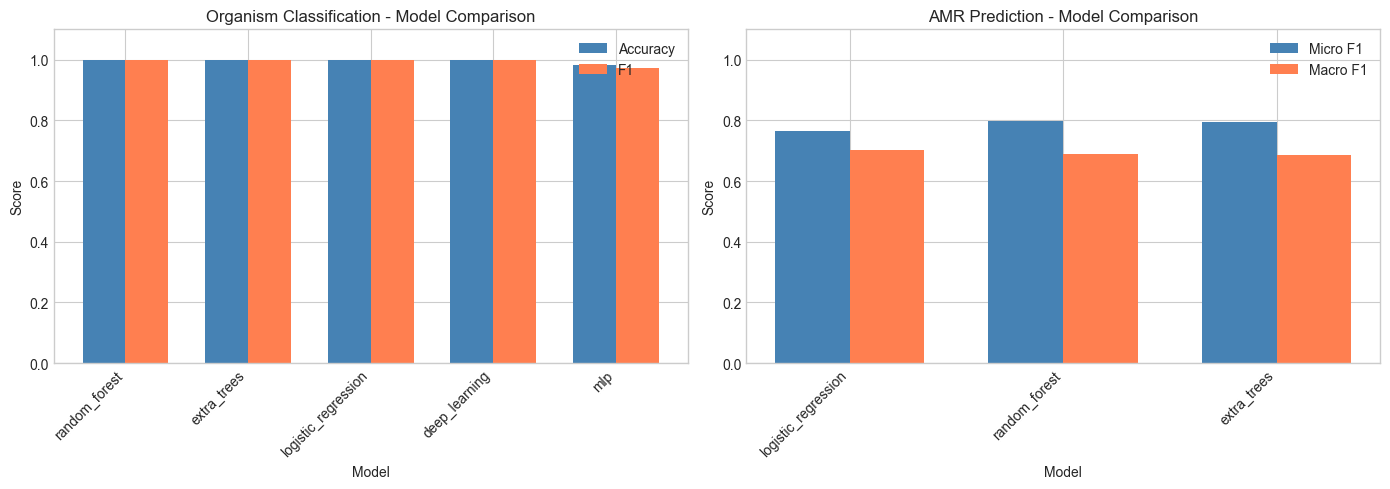

In [17]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Organism classification comparison
models = org_comparison_df['Model'].tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, org_comparison_df['Accuracy'], width, label='Accuracy', color='steelblue')
axes[0].bar(x + width/2, org_comparison_df['F1 (Weighted)'], width, label='F1', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Organism Classification - Model Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# AMR prediction comparison
models = amr_comparison_df['Model'].tolist()
x = np.arange(len(models))

axes[1].bar(x - width/2, amr_comparison_df['Micro F1'], width, label='Micro F1', color='steelblue')
axes[1].bar(x + width/2, amr_comparison_df['Macro F1'], width, label='Macro F1', color='coral')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('AMR Prediction - Model Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 6. Organism Classification Results

In [18]:
# Select best organism classifier
best_org_model_name = org_comparison_df.iloc[0]['Model']
print(f"Best organism classifier: {best_org_model_name}")

if best_org_model_name == 'deep_learning':
    best_org_trainer = dl_organism_results['trainer']
    _, best_org_preds, best_org_probs = best_org_trainer.evaluate(
        organism_data['X_test'], organism_data['y_test']
    )
else:
    best_org_trainer = organism_results[best_org_model_name]['trainer']
    best_org_preds = best_org_trainer.predict(organism_data['X_test'])
    best_org_probs = best_org_trainer.predict_proba(organism_data['X_test'])

Best organism classifier: random_forest


In [19]:
# Classification report
class_names = organism_data['metadata']['class_names']
y_test = organism_data['y_test']

print("Classification Report:")
print("="*70)
print(classification_report(y_test, best_org_preds, target_names=class_names, digits=3))

Classification Report:
                         precision    recall  f1-score   support

Acinetobacter baumannii      1.000     1.000     1.000        56
  Enterococcus faecalis      1.000     1.000     1.000        21
   Enterococcus faecium      1.000     1.000     1.000        11
       Escherichia coli      1.000     1.000     1.000        41
  Klebsiella pneumoniae      1.000     1.000     1.000        16
 Pseudomonas aeruginosa      1.000     1.000     1.000        25
    Salmonella enterica      1.000     1.000     1.000         2
  Staphylococcus aureus      1.000     1.000     1.000         1

               accuracy                          1.000       173
              macro avg      1.000     1.000     1.000       173
           weighted avg      1.000     1.000     1.000       173



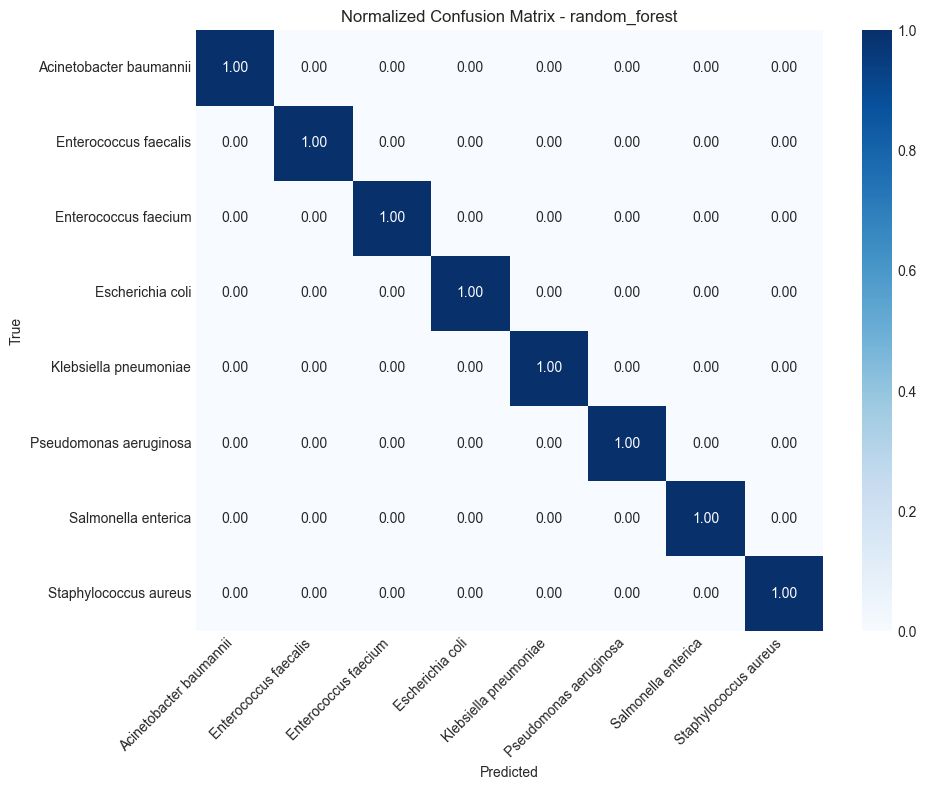


Per-Class Accuracy:
  Acinetobacter baumannii: 100.00%
  Enterococcus faecalis: 100.00%
  Enterococcus faecium: 100.00%
  Escherichia coli: 100.00%
  Klebsiella pneumoniae: 100.00%
  Pseudomonas aeruginosa: 100.00%
  Salmonella enterica: 100.00%
  Staphylococcus aureus: 100.00%


In [20]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

cm = confusion_matrix(y_test, best_org_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Normalized Confusion Matrix - {best_org_model_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    acc = cm_normalized[i, i]
    print(f"  {name}: {acc:.2%}")

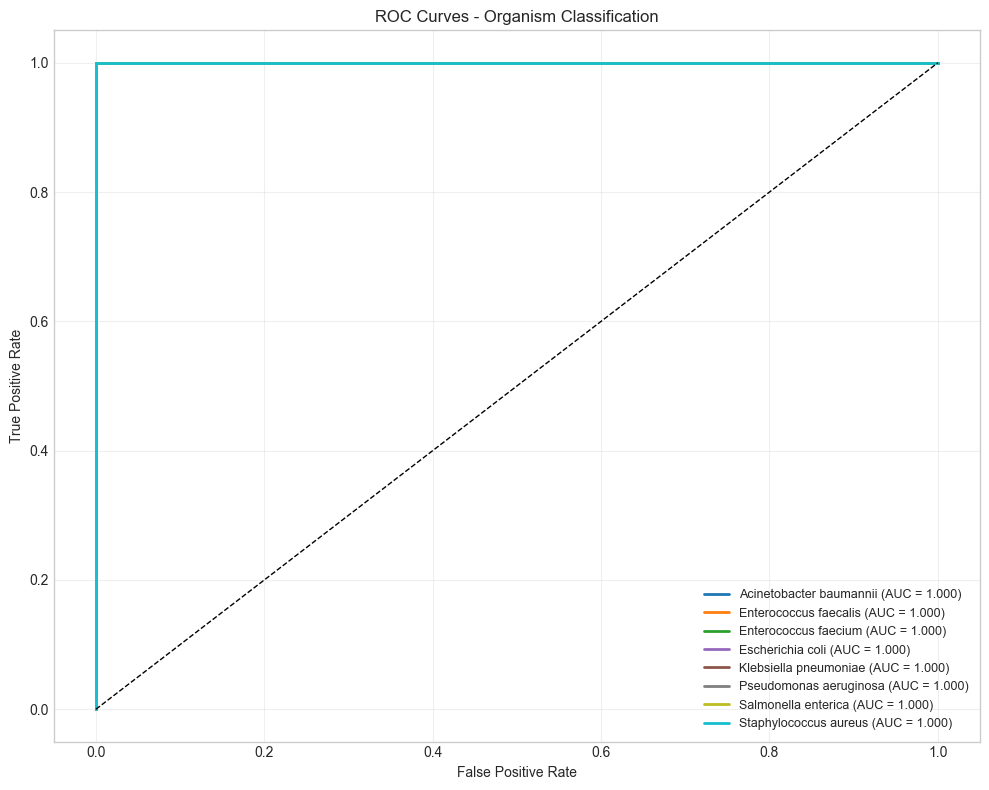

In [22]:
# ROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

for i, (name, color) in enumerate(zip(class_names, colors)):
    # Binary labels for this class
    y_binary = (y_test == i).astype(int)
    y_score = best_org_probs[:, i]
    
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Organism Classification')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. AMR Prediction Results

In [23]:
# Select best AMR predictor
best_amr_model_name = amr_comparison_df.iloc[0]['Model']
print(f"Best AMR predictor: {best_amr_model_name}")

if best_amr_model_name == 'deep_learning':
    best_amr_trainer = dl_amr_results['trainer']
    _, best_amr_preds, best_amr_probs = best_amr_trainer.evaluate(
        amr_data['X_test'], amr_data['y_test']
    )
else:
    best_amr_trainer = amr_results[best_amr_model_name]['trainer']
    best_amr_preds = best_amr_trainer.predict(amr_data['X_test'])
    best_amr_probs = best_amr_trainer.predict_proba(amr_data['X_test'])

Best AMR predictor: logistic_regression


In [24]:
# Per-drug class performance
drug_names = amr_data['metadata']['class_names']
y_test_amr = amr_data['y_test']

drug_results = []
for i, drug in enumerate(drug_names):
    y_true = y_test_amr[:, i]
    y_pred = best_amr_preds[:, i]
    y_prob = best_amr_probs[:, i]
    
    result = {
        'Drug Class': drug,
        'Test Samples': int(y_true.sum()),
        'Prevalence': f"{y_true.mean()*100:.1f}%",
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
    
    if y_true.sum() > 0 and y_true.sum() < len(y_true):
        result['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    else:
        result['ROC-AUC'] = 0
    
    drug_results.append(result)

drug_results_df = pd.DataFrame(drug_results)
drug_results_df = drug_results_df.sort_values('F1', ascending=False)

print("Per-Drug Class Performance:")
display(drug_results_df.style.format({
    'Precision': '{:.3f}',
    'Recall': '{:.3f}',
    'F1': '{:.3f}',
    'ROC-AUC': '{:.3f}',
}).background_gradient(subset=['F1', 'ROC-AUC'], cmap='RdYlGn'))

Per-Drug Class Performance:


,Drug Class,Test Samples,Prevalence,Precision,Recall,F1,ROC-AUC
2,fosfomycin,50,28.9%,0.958,0.920,0.939,0.987
1,beta-lactam,132,76.3%,0.983,0.894,0.937,0.975
3,glycopeptide,10,5.8%,1.000,0.800,0.889,0.998
0,aminoglycoside,138,79.8%,0.914,0.848,0.880,0.834
9,tetracycline,100,57.8%,0.795,0.660,0.721,0.753
4,macrolide,84,48.6%,0.713,0.679,0.695,0.813
5,phenicol,69,39.9%,0.697,0.667,0.681,0.797
8,sulfonamide,81,46.8%,0.653,0.580,0.614,0.702
6,quinolone,31,17.9%,0.789,0.484,0.600,0.901
10,trimethoprim,44,25.4%,0.543,0.432,0.481,0.738


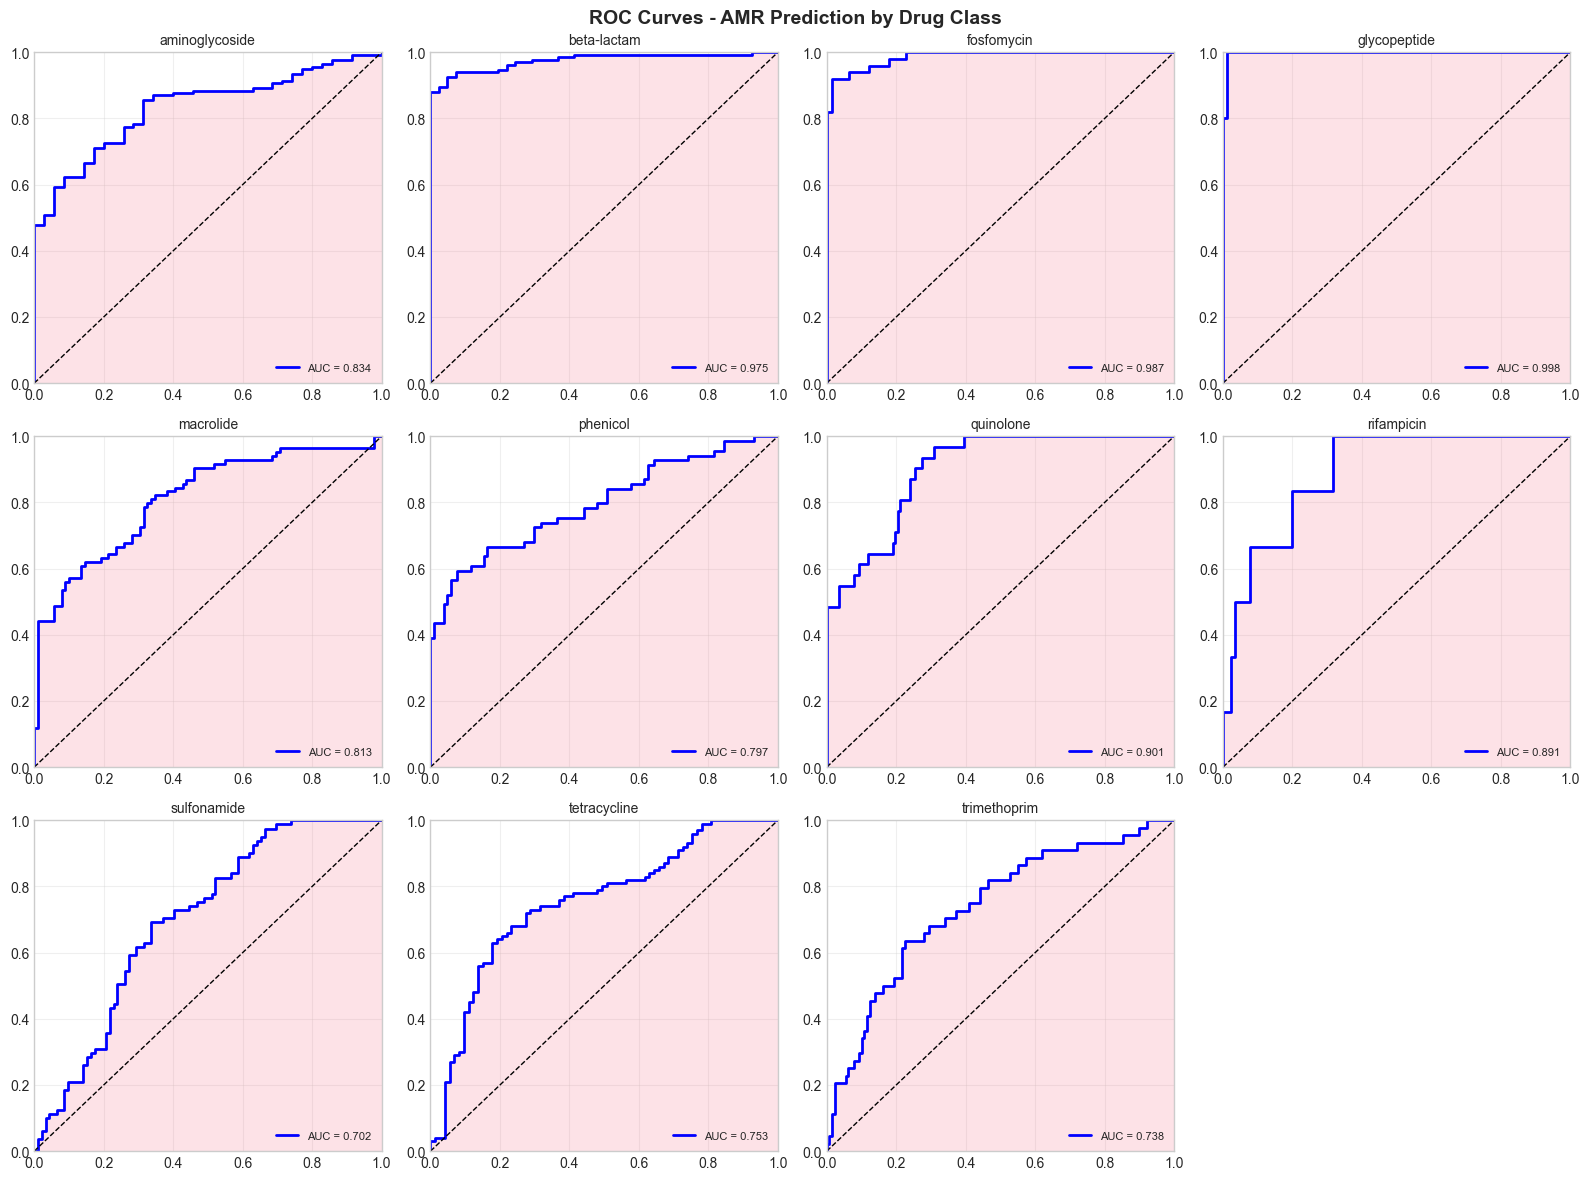

In [25]:
# ROC curves for AMR prediction
n_drugs = len(drug_names)
n_cols = 4
n_rows = (n_drugs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, drug in enumerate(drug_names):
    if i >= len(axes):
        break
        
    y_true = y_test_amr[:, i]
    y_prob = best_amr_probs[:, i]
    
    if y_true.sum() > 0 and y_true.sum() < len(y_true):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        axes[i].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc:.3f}')
        axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1)
        axes[i].fill_between(fpr, tpr, alpha=0.2)
    else:
        axes[i].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
    
    axes[i].set_title(drug, fontsize=10)
    axes[i].legend(loc='lower right', fontsize=8)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(drug_names), len(axes)):
    axes[j].axis('off')

plt.suptitle('ROC Curves - AMR Prediction by Drug Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

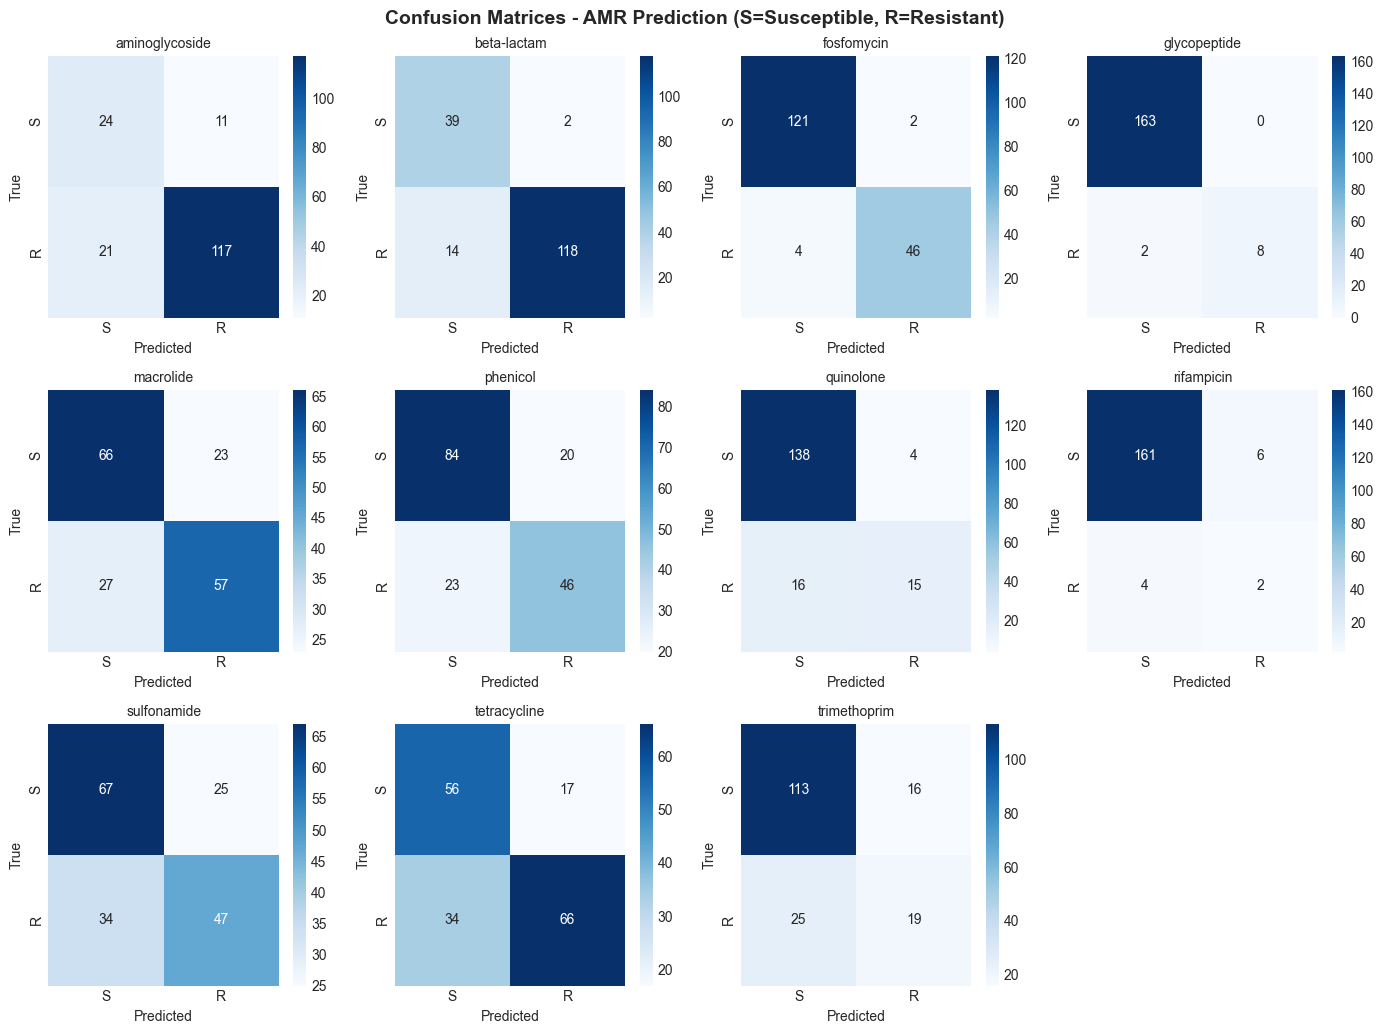

In [26]:
# Confusion matrices for each drug
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5*n_rows))
axes = axes.flatten()

for i, drug in enumerate(drug_names):
    if i >= len(axes):
        break
        
    cm = confusion_matrix(y_test_amr[:, i], best_amr_preds[:, i])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['S', 'R'], yticklabels=['S', 'R'])
    axes[i].set_title(drug, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

for j in range(len(drug_names), len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices - AMR Prediction (S=Susceptible, R=Resistant)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

In [27]:
def get_feature_importance(trainer, feature_names, top_n=30):
    """Extract feature importance from model."""
    model = trainer.model
    
    # Handle OneVsRestClassifier wrapper
    if hasattr(model, 'estimators_'):
        if hasattr(model.estimators_[0], 'feature_importances_'):
            importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)
        elif hasattr(model.estimators_[0], 'coef_'):
            importances = np.mean([np.abs(est.coef_).flatten() for est in model.estimators_], axis=0)
        else:
            return None
    elif hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_).mean(axis=0)
    else:
        return None
    
    # Get top features
    top_indices = np.argsort(importances)[::-1][:top_n]
    top_features = [(feature_names[i], importances[i]) for i in top_indices]
    
    return top_features

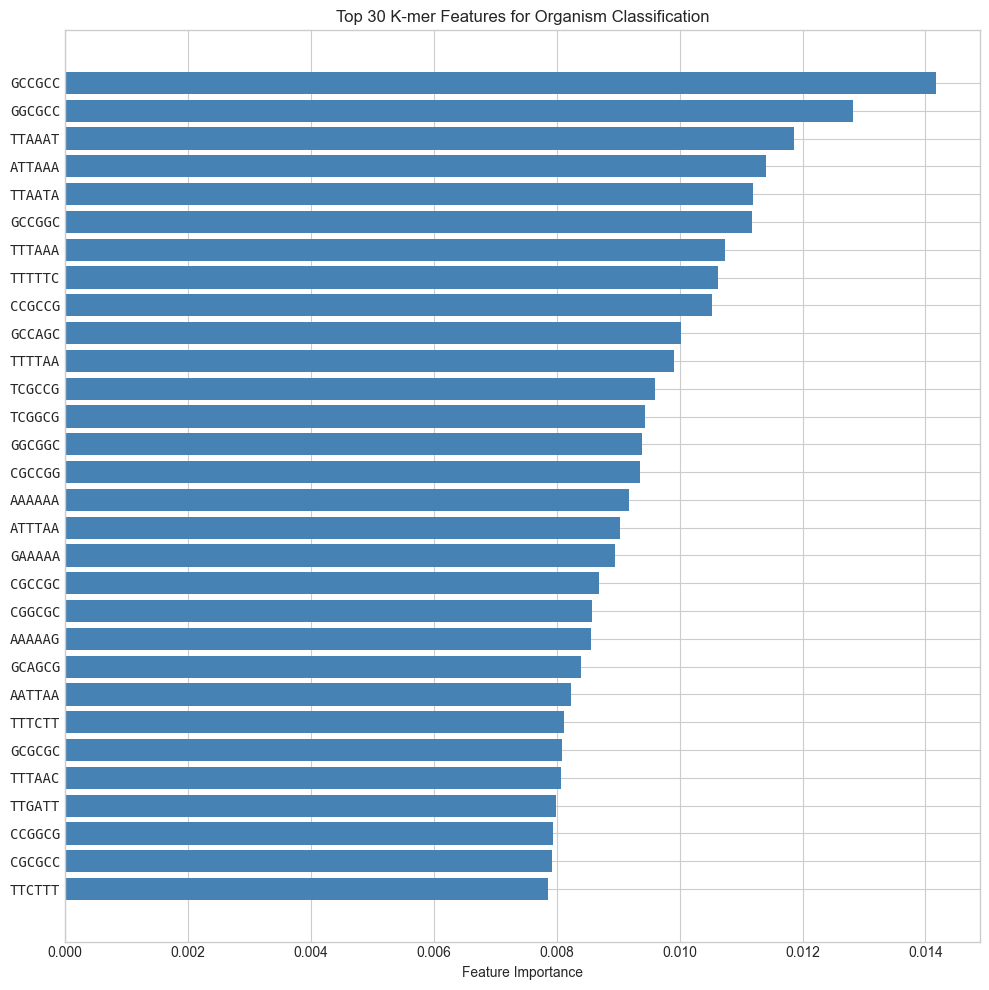


Top 10 K-mer Features:
  1. GCCGCC: 0.014178
  2. GGCGCC: 0.012817
  3. TTAAAT: 0.011862
  4. ATTAAA: 0.011410
  5. TTAATA: 0.011191
  6. GCCGGC: 0.011182
  7. TTTAAA: 0.010737
  8. TTTTTC: 0.010631
  9. CCGCCG: 0.010532
  10. GCCAGC: 0.010023


In [28]:
# Feature importance for organism classification
org_feature_names = organism_data['metadata']['feature_names']

# Use random forest for feature importance
rf_org_trainer = organism_results.get('random_forest', organism_results.get('extra_trees'))
if rf_org_trainer:
    org_top_features = get_feature_importance(rf_org_trainer['trainer'], org_feature_names, top_n=30)
    
    if org_top_features:
        fig, ax = plt.subplots(figsize=(10, 10))
        
        names = [f[0] for f in org_top_features]
        values = [f[1] for f in org_top_features]
        
        y_pos = np.arange(len(names))
        ax.barh(y_pos, values, color='steelblue')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(names, fontfamily='monospace')
        ax.invert_yaxis()
        ax.set_xlabel('Feature Importance')
        ax.set_title('Top 30 K-mer Features for Organism Classification')
        
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 K-mer Features:")
        for i, (name, importance) in enumerate(org_top_features[:10], 1):
            print(f"  {i}. {name}: {importance:.6f}")

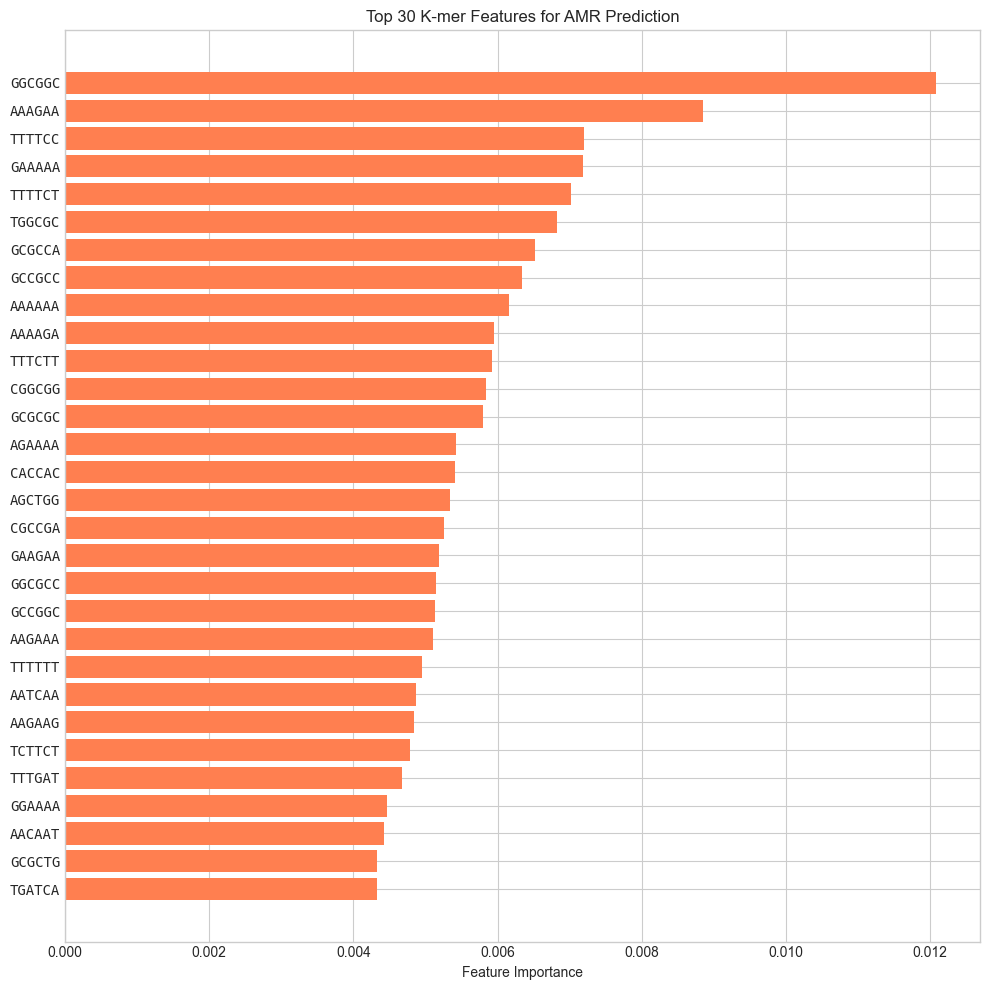


Top 10 K-mer Features:
  1. GGCGGC: 0.012090
  2. AAAGAA: 0.008851
  3. TTTTCC: 0.007206
  4. GAAAAA: 0.007183
  5. TTTTCT: 0.007024
  6. TGGCGC: 0.006824
  7. GCGCCA: 0.006522
  8. GCCGCC: 0.006345
  9. AAAAAA: 0.006164
  10. AAAAGA: 0.005947


In [29]:
# Feature importance for AMR prediction
amr_feature_names = amr_data['metadata']['feature_names']

rf_amr_trainer = amr_results.get('random_forest', amr_results.get('extra_trees'))
if rf_amr_trainer:
    amr_top_features = get_feature_importance(rf_amr_trainer['trainer'], amr_feature_names, top_n=30)
    
    if amr_top_features:
        fig, ax = plt.subplots(figsize=(10, 10))
        
        names = [f[0] for f in amr_top_features]
        values = [f[1] for f in amr_top_features]
        
        y_pos = np.arange(len(names))
        ax.barh(y_pos, values, color='coral')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(names, fontfamily='monospace')
        ax.invert_yaxis()
        ax.set_xlabel('Feature Importance')
        ax.set_title('Top 30 K-mer Features for AMR Prediction')
        
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 K-mer Features:")
        for i, (name, importance) in enumerate(amr_top_features[:10], 1):
            print(f"  {i}. {name}: {importance:.6f}")

## 9. Making Predictions

In [30]:
class DeepAMRPredictor:
    """Unified predictor class for making predictions on new data."""
    
    def __init__(self, organism_trainer, amr_trainer, organism_metadata, amr_metadata):
        self.organism_trainer = organism_trainer
        self.amr_trainer = amr_trainer
        self.organism_classes = organism_metadata['class_names']
        self.drug_classes = amr_metadata['class_names']
    
    def predict_organism(self, X):
        """Predict organism from k-mer features."""
        preds = self.organism_trainer.predict(X)
        probs = self.organism_trainer.predict_proba(X)
        
        results = []
        for i, (pred, prob) in enumerate(zip(preds, probs)):
            results.append({
                'predicted_organism': self.organism_classes[pred],
                'confidence': float(prob[pred]),
                'all_probabilities': {cls: float(p) for cls, p in zip(self.organism_classes, prob)}
            })
        
        return results
    
    def predict_amr(self, X, threshold=0.5):
        """Predict AMR from k-mer features."""
        probs = self.amr_trainer.predict_proba(X)
        preds = (probs > threshold).astype(int)
        
        results = []
        for i, (pred, prob) in enumerate(zip(preds, probs)):
            resistant_drugs = [drug for drug, p in zip(self.drug_classes, pred) if p == 1]
            results.append({
                'resistant_to': resistant_drugs,
                'susceptible_to': [d for d in self.drug_classes if d not in resistant_drugs],
                'probabilities': {drug: float(p) for drug, p in zip(self.drug_classes, prob)},
                'multi_drug_resistant': len(resistant_drugs) >= 3,
            })
        
        return results
    
    def predict_full(self, X, amr_threshold=0.5):
        """Full prediction: organism + AMR."""
        org_results = self.predict_organism(X)
        amr_results = self.predict_amr(X, threshold=amr_threshold)
        
        combined = []
        for org, amr in zip(org_results, amr_results):
            combined.append({
                'organism': org,
                'amr': amr,
            })
        
        return combined

In [31]:
# Create unified predictor
predictor = DeepAMRPredictor(
    organism_trainer=organism_results[best_org_model_name]['trainer'],
    amr_trainer=amr_results[best_amr_model_name]['trainer'],
    organism_metadata=organism_data['metadata'],
    amr_metadata=amr_data['metadata']
)

# Test on a few samples
X_sample = organism_data['X_test'][:5]

print("Sample Predictions:")
print("="*70)

results = predictor.predict_full(X_sample)

for i, res in enumerate(results):
    print(f"\nSample {i+1}:")
    print(f"  Organism: {res['organism']['predicted_organism']} "
          f"(confidence: {res['organism']['confidence']:.2%})")
    print(f"  Resistant to: {', '.join(res['amr']['resistant_to']) or 'None'}")
    print(f"  Multi-drug resistant: {res['amr']['multi_drug_resistant']}")

Sample Predictions:

Sample 1:
  Organism: Enterococcus faecalis (confidence: 95.50%)
  Resistant to: aminoglycoside, beta-lactam, fosfomycin, macrolide, phenicol, quinolone
  Multi-drug resistant: True

Sample 2:
  Organism: Enterococcus faecalis (confidence: 98.00%)
  Resistant to: aminoglycoside, beta-lactam, fosfomycin, quinolone, tetracycline
  Multi-drug resistant: True

Sample 3:
  Organism: Pseudomonas aeruginosa (confidence: 100.00%)
  Resistant to: aminoglycoside, phenicol, rifampicin, sulfonamide, tetracycline
  Multi-drug resistant: True

Sample 4:
  Organism: Klebsiella pneumoniae (confidence: 97.00%)
  Resistant to: aminoglycoside, rifampicin, sulfonamide, tetracycline
  Multi-drug resistant: True

Sample 5:
  Organism: Acinetobacter baumannii (confidence: 98.51%)
  Resistant to: aminoglycoside, beta-lactam, fosfomycin, macrolide, phenicol
  Multi-drug resistant: True


## 10. Clinical Impact Analysis

In [33]:
# Analyze clinical impact for Bangladesh context
print("Clinical Impact Analysis for Bangladesh")
print("="*60)

# Key antibiotics commonly used in Bangladesh
priority_drugs = ['beta-lactam', 'aminoglycoside', 'quinolone', 'macrolide', 'tetracycline']
available_drugs = [d for d in priority_drugs if d in drug_names]

print(f"\nPriority antibiotics in Bangladesh context:")
for drug in available_drugs:
    drug_idx = drug_names.index(drug)
    prevalence = y_test_amr[:, drug_idx].mean() * 100
    
    # Get performance metrics
    drug_row = drug_results_df[drug_results_df['Drug Class'] == drug].iloc[0]
    f1 = drug_row['F1']
    
    print(f"\n  {drug}:")
    print(f"    - Resistance prevalence: {prevalence:.1f}%")
    print(f"    - Model F1 score: {f1:.3f}")

Clinical Impact Analysis for Bangladesh

Priority antibiotics in Bangladesh context:

  beta-lactam:
    - Resistance prevalence: 76.3%
    - Model F1 score: 0.937

  aminoglycoside:
    - Resistance prevalence: 79.8%
    - Model F1 score: 0.880

  quinolone:
    - Resistance prevalence: 17.9%
    - Model F1 score: 0.600

  macrolide:
    - Resistance prevalence: 48.6%
    - Model F1 score: 0.695

  tetracycline:
    - Resistance prevalence: 57.8%
    - Model F1 score: 0.721


In [33]:
# Treatment recommendation simulation
print("\nTreatment Recommendation Simulation")
print("="*60)

# Define treatment lines
first_line = ['beta-lactam', 'aminoglycoside']
second_line = ['quinolone', 'macrolide']

recommendations = []
for i in range(min(10, len(best_amr_preds))):
    resistant = [drug_names[j] for j in range(len(drug_names)) if best_amr_preds[i, j] == 1]
    
    # Find suitable treatment
    first_line_available = [d for d in first_line if d in drug_names and d not in resistant]
    second_line_available = [d for d in second_line if d in drug_names and d not in resistant]
    
    if first_line_available:
        recommendation = f"First-line: {first_line_available[0]}"
    elif second_line_available:
        recommendation = f"Second-line: {second_line_available[0]}"
    else:
        recommendation = "Consult specialist - extensive resistance"
    
    recommendations.append({
        'sample': i + 1,
        'resistant_to': resistant,
        'recommendation': recommendation
    })

print("\nSample Treatment Recommendations:")
for rec in recommendations[:5]:
    print(f"  Sample {rec['sample']}:")
    print(f"    Resistant to: {', '.join(rec['resistant_to']) or 'None'}")
    print(f"    Recommendation: {rec['recommendation']}")


Treatment Recommendation Simulation

Sample Treatment Recommendations:
  Sample 1:
    Resistant to: aminoglycoside
    Recommendation: First-line: beta-lactam
  Sample 2:
    Resistant to: macrolide
    Recommendation: First-line: beta-lactam
  Sample 3:
    Resistant to: beta-lactam, macrolide, tetracycline
    Recommendation: First-line: aminoglycoside
  Sample 4:
    Resistant to: None
    Recommendation: First-line: beta-lactam
  Sample 5:
    Resistant to: aminoglycoside, beta-lactam, sulfonamide, tetracycline
    Recommendation: Second-line: quinolone



Multi-Drug Resistance Analysis
Total test samples: 173
MDR samples (>=3 drug classes): 133 (76.9%)
Mean drug classes resistant: 3.86
Max drug classes resistant: 9


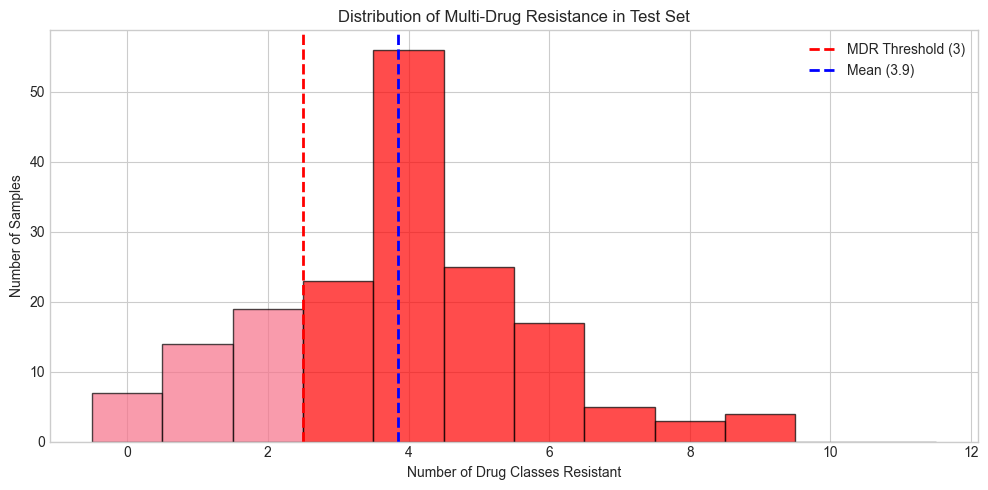

In [34]:
# Multi-drug resistance analysis
print("\nMulti-Drug Resistance Analysis")
print("="*60)

resistance_counts = best_amr_preds.sum(axis=1)
mdr_threshold = 3

mdr_samples = (resistance_counts >= mdr_threshold).sum()
mdr_percentage = mdr_samples / len(resistance_counts) * 100

print(f"Total test samples: {len(resistance_counts)}")
print(f"MDR samples (>={mdr_threshold} drug classes): {mdr_samples} ({mdr_percentage:.1f}%)")
print(f"Mean drug classes resistant: {resistance_counts.mean():.2f}")
print(f"Max drug classes resistant: {resistance_counts.max()}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))

bins = range(0, len(drug_names) + 2)
counts, _, patches = ax.hist(resistance_counts, bins=bins, edgecolor='black', alpha=0.7, align='left')

# Color MDR samples differently
for i, patch in enumerate(patches):
    if i >= mdr_threshold:
        patch.set_facecolor('red')
        patch.set_alpha(0.7)

ax.axvline(mdr_threshold - 0.5, color='red', linestyle='--', linewidth=2, label=f'MDR Threshold ({mdr_threshold})')
ax.axvline(resistance_counts.mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'Mean ({resistance_counts.mean():.1f})')

ax.set_xlabel('Number of Drug Classes Resistant')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Multi-Drug Resistance in Test Set')
ax.legend()

plt.tight_layout()
plt.show()

## 11. Model Export & Deployment

In [35]:
# Save best models
print("Saving best models...")

# Save organism classifier
org_model_path = MODELS_DIR / 'organism_classifier.joblib'
organism_results[best_org_model_name]['trainer'].save(str(org_model_path))

# Save AMR predictor
amr_model_path = MODELS_DIR / 'amr_predictor.joblib'
amr_results[best_amr_model_name]['trainer'].save(str(amr_model_path))

# Save model metadata and results
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'organism_classifier': {
        'model_name': best_org_model_name,
        'test_metrics': organism_results[best_org_model_name]['test_metrics'],
        'class_names': organism_data['metadata']['class_names'],
    },
    'amr_predictor': {
        'model_name': best_amr_model_name,
        'test_metrics': amr_results[best_amr_model_name]['test_metrics'],
        'drug_classes': amr_data['metadata']['class_names'],
    },
    'model_comparison': {
        'organism': org_comparison_df.to_dict('records'),
        'amr': amr_comparison_df.to_dict('records'),
    }
}

with open(MODELS_DIR / 'model_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

print(f"\nModels saved to: {MODELS_DIR}")
print(f"  - organism_classifier.joblib")
print(f"  - amr_predictor.joblib")
print(f"  - model_results.json")

Saving best models...
Model saved to /Users/jubayer/Projects/DeepAMR/models/organism_classifier.joblib
Model saved to /Users/jubayer/Projects/DeepAMR/models/amr_predictor.joblib

Models saved to: /Users/jubayer/Projects/DeepAMR/models
  - organism_classifier.joblib
  - amr_predictor.joblib
  - model_results.json


In [36]:
# Save deep learning models if available
if TORCH_AVAILABLE and dl_organism_results:
    dl_org_path = MODELS_DIR / 'organism_classifier_dl.pt'
    dl_organism_results['trainer'].save(str(dl_org_path))
    print(f"Deep learning organism classifier saved to: {dl_org_path}")

if TORCH_AVAILABLE and dl_amr_results:
    dl_amr_path = MODELS_DIR / 'amr_predictor_dl.pt'
    dl_amr_results['trainer'].save(str(dl_amr_path))
    print(f"Deep learning AMR predictor saved to: {dl_amr_path}")

Model saved to /Users/jubayer/Projects/DeepAMR/models/organism_classifier_dl.pt
Deep learning organism classifier saved to: /Users/jubayer/Projects/DeepAMR/models/organism_classifier_dl.pt


In [37]:
# Final summary
print("="*70)
print("TRAINING & EVALUATION COMPLETE")
print("="*70)

print("\n--- Organism Classification ---")
print(f"Best model: {best_org_model_name}")
best_org_metrics = organism_results[best_org_model_name]['test_metrics']
print(f"Test Accuracy: {best_org_metrics.get('accuracy', 0):.4f}")
print(f"Test F1 (Weighted): {best_org_metrics.get('f1', 0):.4f}")
print(f"Test F1 (Macro): {best_org_metrics.get('f1_macro', 0):.4f}")

print("\n--- AMR Prediction ---")
print(f"Best model: {best_amr_model_name}")
best_amr_metrics = amr_results[best_amr_model_name]['test_metrics']
print(f"Test Micro F1: {best_amr_metrics.get('micro_f1', 0):.4f}")
print(f"Test Macro F1: {best_amr_metrics.get('macro_f1', 0):.4f}")
print(f"Test Hamming Loss: {best_amr_metrics.get('hamming_loss', 0):.4f}")

print("\n--- Next Steps ---")
print("1. Deploy models via FastAPI for web-based predictions")
print("2. Integrate with frontend application")
print("3. Validate on external datasets")
print("4. Conduct clinical validation studies")

TRAINING & EVALUATION COMPLETE

--- Organism Classification ---
Best model: random_forest
Test Accuracy: 1.0000
Test F1 (Weighted): 1.0000
Test F1 (Macro): 1.0000

--- AMR Prediction ---
Best model: logistic_regression
Test Micro F1: 0.7663
Test Macro F1: 0.7021
Test Hamming Loss: 0.1734

--- Next Steps ---
1. Deploy models via FastAPI for web-based predictions
2. Integrate with frontend application
3. Validate on external datasets
4. Conduct clinical validation studies
